## CIFAR-10 zero-shot classifier with Resnet50
In this notebook, we provide a use-case of our method.
We use a Resnet50 model (pre-trained on ImageNet) and leverage Text-To-Concept to turn it into a zero-shot classifer on CIFAR-10.
This notebook has these sections:
+ <i>Preliminaries</i>: we import required libraries and load transformations.
+ <i>Resnet50</i>: we load the model and implement its necessary functions, enabling us to use `TextToConcept` framework.
+ <i>Linear Aligner</i>: we initiate `TextToConcept` object and train/load its linear aligner.
+ <i>Zero-shot classifier</i>: we use methods implemented in `TextToConcept` and appropriate text prompts to get the zero-shot classifer.
+ <i>Zero-shot performance on CIFAR-10</i>: we load CIFAR-10 and evaluate Resnet50-based zero-shot classifier on it. 


### Preliminaries
In this section, we import the required libraries and initialize standard transformations necessary for loading datasets. It is worth mentioning that certain models require input normalization, while others do not.

In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torchvision
import numpy as np
from tqdm import tqdm
from TextToConcept import TextToConcept

/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/Users/rodrigopaganini/master/xai/project/Text-to-concept/ViCLIP/viclip_text.py:4: UserWarning: pkg_res

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

In [3]:
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = 'mps'

In [4]:
# std_transform_without_normalization = torchvision.transforms.Compose([
#     torchvision.transforms.Resize(224),
#     torchvision.transforms.CenterCrop(224),
#     torchvision.transforms.ToTensor()])


# std_transform_with_normalization = torchvision.transforms.Compose([
#     torchvision.transforms.Resize(224),
#     torchvision.transforms.CenterCrop(224),
#     torchvision.transforms.ToTensor(), 
#     torchvision.transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

### Resnet50
In this part, we load Resnet50 model.
In order to use ``TextToConcept`` framework, model should implement these functions/attributes:
+ ``forward_features(x)`` that takes a tensor as the input and outputs the representation (features) of input $x$ when it is passed through the model.
+ ``get_normalizer`` should be the normalizer that the models uses to preprocess the input. e.g., Resnet18, uses standard ImageNet normalizer.
+ Attribute ``has_normalizer`` should be `True` when normalizer is need for the model.

In [5]:
import kagglehub

# Download latest version
# path = kagglehub.dataset_download("ambityga/imagenet100")
path = "~/.cache/kagglehub/datasets/ambityga/imagenet100"  # already downloaded

print("Path to dataset files:", path)

Path to dataset files: ~/.cache/kagglehub/datasets/ambityga/imagenet100


In [8]:
from transformers import VideoMAEVideoProcessor, VideoMAEForVideoClassification
import torchvision

IMAGENET_MEAN = (0.485, 0.456, 0.406)  # TODO review mean and std for norm
IMAGENET_STD = (0.229, 0.224, 0.225)


class VideoMAETToTWrapper(torch.nn.Module):
    def __init__(self, model, normalizer = None, mtype="videomae"):
        super().__init__()
        self.model = model
        self.normalizer = normalizer

    def forward_features(self, x):
        sequence_videomae_feats = self.model.videomae(**x).last_hidden_state

        if self.model.fc_norm is not None:
            videomae_feats = sequence_videomae_feats.mean(1)
            videomae_feats = self.model.fc_norm(videomae_feats)
        else:
            videomae_feats = sequence_videomae_feats[:, 0]

        return videomae_feats

    def get_normalizer(self, x):
        if self.normalizer is None:
            return x
        return self.normalizer(x)

    @property
    def has_normalizer(self):
        return self.normalizer is not None


device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
feature_extractor = VideoMAEVideoProcessor.from_pretrained("MCG-NJU/videomae-small-finetuned-ssv2")
videomae_model = VideoMAEForVideoClassification.from_pretrained("MCG-NJU/videomae-small-finetuned-ssv2")
videomae_model = videomae_model.to(device)

model = VideoMAETToTWrapper(videomae_model, normalizer=torchvision.transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD))

Loading weights: 100%|██████████| 186/186 [00:00<00:00, 41518.92it/s]


### Linear Aligner

<b>Initiating Text-To-Concept Object</b><br>
In this section, we initiate ``TextToConcept`` object which turns the vision encoder (e.g., Resnet50) into a model capable of integrating language and vision. By doing so, we enable the utilization of certain abilities present in vision-language models.

In [9]:
text_to_concept = TextToConcept(model, 'videomae', 'video')

We can either train the aligner or load an existing one.

#### Training Linear Aligner

<b>Loading ImageNet Dataset to Train the Aligner</b><br>
We note that even $20\%$ of ImageNet training samples suffices for training an effective linear aligner. 
We refer to Appendix A of our paper for more details on sample efficiency of linear alignment.

In [16]:
# std_transform_without_normalization = torchvision.transforms.Compose([
#     torchvision.transforms.Resize(224),
#     torchvision.transforms.CenterCrop(224),
#     torchvision.transforms.ToTensor()])


# std_transform_with_normalization = torchvision.transforms.Compose([
#     torchvision.transforms.Resize(224),
#     torchvision.transforms.CenterCrop(224),
#     torchvision.transforms.ToTensor(), 
#     torchvision.transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)])

from pytorchvideo.transforms import UniformTemporalSubsample, ApplyTransformToKey, Normalize
from pytorchvideo.data import LabeledVideoDataset, UniformClipSampler
from torchvision.transforms import Compose, Lambda, ToTensor
from torchvision.transforms import Resize, CenterCrop

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class ToTensorTuple:
    def __init__(self, key_list):
        self.key_list = key_list

    def __call__(self, x, *args, **kwds):
        return tuple(x[key] for key in self.key_list)  # TODO see batching


class DivideBy255:
    def __call__(self, x):
        return x / 255.0


class CTHWToTCHW:
    def __call__(self, x):
        return x.permute(1, 0, 2, 3)


preprocessing_without_normalization = Compose([
    ApplyTransformToKey(
        key="video",
        transform=Compose([
            UniformTemporalSubsample(8),
            DivideBy255(),
            Resize((224, 224)),
            CenterCrop(224),
            CTHWToTCHW(),
            # Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),
    ),
    ToTensorTuple(['video', 'label']),
])


In [17]:
# # loading imagenet dataset to train aligner.
# dset = torchvision.datasets.ImageNet(
#     # root='/fs/cml-datasets/ImageNet/ILSVRC2012',
#     root='.cache/kagglehub/datasets/ambityga/imagenet100',
#     split='train',
#     transform=preprocessing_without_normalization,
# )
import json
from video_utils import make_dataset
from pathlib import Path

SSV2_ROOT = Path("datasets/ssv2")
LABELS_DIR = SSV2_ROOT / "20bn-something-something-download-package-labels" / "labels"  # contains train.json, validation.json, test.json, labels.json
VIDEO_DIR = SSV2_ROOT / "extracted" / "20bn-something-something-v2"  # contains <id>.webm

with open(LABELS_DIR / "labels.json") as f:
    class_to_idx = json.load(f)
labeled_video_paths=make_dataset(
    SSV2_ROOT / "extracted" / "20bn-something-something-v2",
    class_to_idx,
    ".webm"
)
clip_sampler = UniformClipSampler(clip_duration=3.0)

dset = LabeledVideoDataset(
    labeled_video_paths=labeled_video_paths,
    clip_sampler=clip_sampler,
    transform=preprocessing_without_normalization,
)

# 20% of videos are fairly enough.
num_of_samples = int(0.2 * len(labeled_video_paths))
dset = torch.utils.data.Subset(dset, np.random.choice(np.arange(len(labeled_video_paths)), num_of_samples, replace=False))

In [18]:
# # Load the Kaggle dataset as a torchvision ImageFolder dataset
# from pathlib import Path
# import os
# kaggle_dataset_path = os.path.expanduser("~/.cache/kagglehub/datasets/ambityga/imagenet100/versions/8")
# # You may need to adjust the subfolder (e.g., 'train', 'val') depending on the dataset structure
# dset = torchvision.datasets.ImageFolder(
#     root=os.path.join(kaggle_dataset_path, "train.X1"),
#     transform=std_transform_without_normalization,
#     # If you want normalization, use std_transform_with_normalization
#     # transform=std_transform_with_normalization,
#     )

<b>Training the Linear Aligner</b><br>
After loading the object, we need to train the aligner.
+ In order to train the aligner, ``train_linear_aligner`` should be called which obtains representations of the given model (e.g., Resnet50) on ``dset`` as well that of a vision-language model such as CLIP. These representations can also be loaded. Next, this function solves the linear transformation and obtain optimal alignment from model's space to vision-language space.
+ By calling the function ``save_linear_aligner``, linear aliger will be stored which can be utilized later.

In [ ]:
text_to_concept.train_linear_aligner(dset,
                                     load_reps=False,)

text_to_concept.save_linear_aligner('videomae_ssv2_aligner.pth')

Obtaining representations ...


  0%|          | 0/480343 [00:00<?, ?it/s]Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Users/rodrigopaganini/miniconda3/envs/mva-t2c/lib/python3.10/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'DivideBy255' on <module '__main__' (built-in)>


<b>Loading the Linear Aligner</b><br>
We can also use an already existing linear aligner, to do so, we use the function ``load_linear_aligner``.

In [12]:
text_to_concept.load_linear_aligner('imagenet_resnet50_aligner.pth')

FileNotFoundError: [Errno 2] No such file or directory: 'imagenet_resnet50_aligner.pth'

### Zero-shot Classifier
We note that CIFAR-10 is a <i>$10$-way</i> classification problem. 
We use prompts of the form `a pixelated of {c}` to get appropriate concepts in vision-language space.

In [14]:
cifar_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [15]:
cifar_zeroshot_classifier = text_to_concept.get_zero_shot_classifier(cifar_classes,
                                                                     prompts=['a pixelated photo of a {}'])

### Zero-shot performance on CIFAR-10
After loading CIFAR-10, we use `cifar_zeroshot_classifier(x)` to get logits of the classification problem when input $x$ is given.

In [16]:
cifar = torchvision.datasets.CIFAR10(root='data/',
                                     download=True,
                                     train=False,
                                     transform=std_transform_with_normalization)

100%|██████████| 170M/170M [00:16<00:00, 10.3MB/s] 


In [17]:
loader = torch.utils.data.DataLoader(cifar, batch_size=16, shuffle=True, num_workers=8)
correct, total = 0, 0
with torch.no_grad():
    for data in tqdm(loader):
        x, y = data[:2]
        x = x.to(device)

        outputs = cifar_zeroshot_classifier(x).detach().cpu()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()

100%|██████████| 625/625 [15:15<00:00,  1.46s/it]


In [19]:
len(cifar_classes)

10

In [18]:
f'ResNet50 Zeroshot Accuracy on CIFAR-10 {100.*correct/total:.2f}'

'ResNet50 Zeroshot Accuracy on CIFAR-10 33.33'

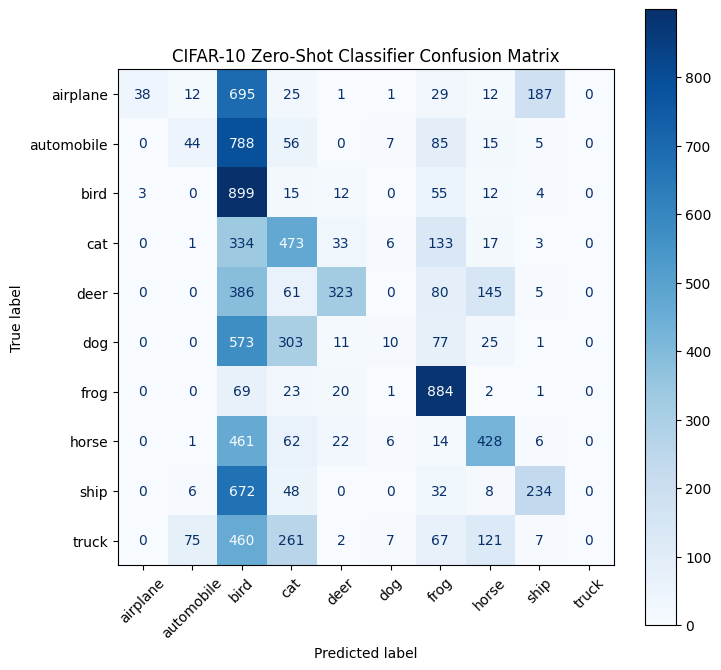

In [21]:
# Plot confusion matrix for CIFAR-10 zero-shot classifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Collect all predictions and true labels
all_preds = []
all_labels = []
with torch.no_grad():
    for data in loader:
        x, y = data[:2]
        x = x.to(device)
        outputs = cifar_zeroshot_classifier(x).detach().cpu()
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cifar_classes)
fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('CIFAR-10 Zero-Shot Classifier Confusion Matrix')
plt.show()

# This classification makes sense